In [1]:
from google.colab import files
uploaded = files.upload()   # select churn-bigml-20.csv

Saving churn-bigml-20.csv to churn-bigml-20.csv


In [2]:
# ── STEP 0: Upload file in Google Colab ─────────────────────
# Run this cell FIRST to upload your CSV file:
#
# from google.colab import files
# uploaded = files.upload()   # select churn-bigml-20.csv


# ── Imports ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc
)
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")


In [3]:
# ============================================================
# STEP 1: Load & Explore the Dataset
# ============================================================

df = pd.read_csv("churn-bigml-20.csv")   # <-- update if filename differs

print("=" * 60)
print("STEP 1: Dataset Overview")
print("=" * 60)
print(f"\nShape : {df.shape[0]} rows × {df.shape[1]} columns")
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum().to_string())
print("\nTarget distribution (Churn):")
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True).mul(100).round(2).astype(str) + " %")

STEP 1: Dataset Overview

Shape : 667 rows × 20 columns

First 5 rows:
  State  Account length  Area code International plan Voice mail plan  \
0    LA             117        408                 No              No   
1    IN              65        415                 No              No   
2    NY             161        415                 No              No   
3    SC             111        415                 No              No   
4    HI              49        510                 No              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                      0              184.5               97   
1                      0              129.1              137   
2                      0              332.9               67   
3                      0              110.4              103   
4                      0              119.3              117   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             31.37         

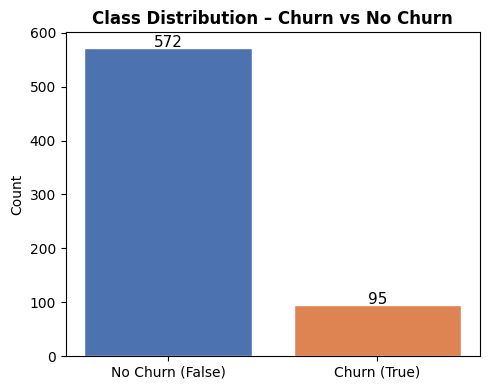

Saved: class_distribution.png


In [4]:
# ── Class imbalance bar chart ─────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["Churn"].value_counts()
ax.bar(["No Churn (False)", "Churn (True)"], counts.values,
       color=["#4C72B0", "#DD8452"], edgecolor="white")
for i, v in enumerate(counts.values):
    ax.text(i, v + 1, str(v), ha="center", fontsize=11)
ax.set_title("Class Distribution – Churn vs No Churn", fontweight="bold")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()
print("Saved: class_distribution.png")

In [5]:
# ============================================================
# STEP 2: Preprocessing
# ============================================================

print("\n" + "=" * 60)
print("STEP 2: Preprocessing")
print("=" * 60)

df_clean = df.copy()

# Encode binary categorical features
le = LabelEncoder()
df_clean["International plan"] = le.fit_transform(df_clean["International plan"])
df_clean["Voice mail plan"]     = le.fit_transform(df_clean["Voice mail plan"])

# Drop low-signal / high-cardinality columns
df_clean.drop(columns=["State", "Area code"], inplace=True)

# Encode target
df_clean["Churn"] = df_clean["Churn"].astype(int)

print("Columns used:", df_clean.columns.tolist())

X = df_clean.drop(columns=["Churn"])
y = df_clean["Churn"]

# ── Feature Scaling (CRITICAL for SVM) ───────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)



STEP 2: Preprocessing
Columns used: ['Account length', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']


In [6]:
# ============================================================
# STEP 3: Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}")



Train: 533 | Test: 134


In [7]:
# ============================================================
# STEP 4: Train SVM with Linear Kernel
# ============================================================

print("\n" + "=" * 60)
print("STEP 4: SVM — Linear Kernel")
print("=" * 60)

svm_linear = SVC(kernel="linear", C=1.0, probability=True, random_state=42)
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)
y_prob_linear = svm_linear.predict_proba(X_test)[:, 1]

print("\nClassification Report (Linear):")
print(classification_report(y_test, y_pred_linear, target_names=["No Churn", "Churn"]))
print(f"AUC-ROC : {roc_auc_score(y_test, y_prob_linear):.4f}")


STEP 4: SVM — Linear Kernel

Classification Report (Linear):
              precision    recall  f1-score   support

    No Churn       0.86      1.00      0.92       115
       Churn       0.00      0.00      0.00        19

    accuracy                           0.86       134
   macro avg       0.43      0.50      0.46       134
weighted avg       0.74      0.86      0.79       134

AUC-ROC : 0.7840


In [8]:
# ============================================================
# STEP 5: Train SVM with RBF Kernel
# ============================================================

print("\n" + "=" * 60)
print("STEP 5: SVM — RBF Kernel")
print("=" * 60)

svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42)
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)
y_prob_rbf = svm_rbf.predict_proba(X_test)[:, 1]

print("\nClassification Report (RBF):")
print(classification_report(y_test, y_pred_rbf, target_names=["No Churn", "Churn"]))
print(f"AUC-ROC : {roc_auc_score(y_test, y_prob_rbf):.4f}")


STEP 5: SVM — RBF Kernel

Classification Report (RBF):
              precision    recall  f1-score   support

    No Churn       0.90      1.00      0.95       115
       Churn       1.00      0.32      0.48        19

    accuracy                           0.90       134
   macro avg       0.95      0.66      0.71       134
weighted avg       0.91      0.90      0.88       134

AUC-ROC : 0.9309


In [9]:
# ============================================================
# STEP 6: Hyperparameter Tuning with GridSearchCV (RBF)
# ============================================================

print("\n" + "=" * 60)
print("STEP 6: Hyperparameter Tuning — GridSearchCV (RBF)")
print("=" * 60)

param_grid = {
    "C"    : [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.1]
}

grid_rbf = GridSearchCV(
    SVC(kernel="rbf", probability=True, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)
grid_rbf.fit(X_train, y_train)

print(f"\nBest Params  : {grid_rbf.best_params_}")
print(f"Best CV F1   : {grid_rbf.best_score_:.4f}")

svm_best = grid_rbf.best_estimator_
y_pred_best = svm_best.predict(X_test)
y_prob_best = svm_best.predict_proba(X_test)[:, 1]

print("\nTuned RBF Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=["No Churn", "Churn"]))
print(f"AUC-ROC : {roc_auc_score(y_test, y_prob_best):.4f}")


STEP 6: Hyperparameter Tuning — GridSearchCV (RBF)
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best Params  : {'C': 10, 'gamma': 0.01}
Best CV F1   : 0.5226

Tuned RBF Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.98      0.94       115
       Churn       0.75      0.32      0.44        19

    accuracy                           0.89       134
   macro avg       0.82      0.65      0.69       134
weighted avg       0.88      0.89      0.87       134

AUC-ROC : 0.8778



STEP 7: Confusion Matrices


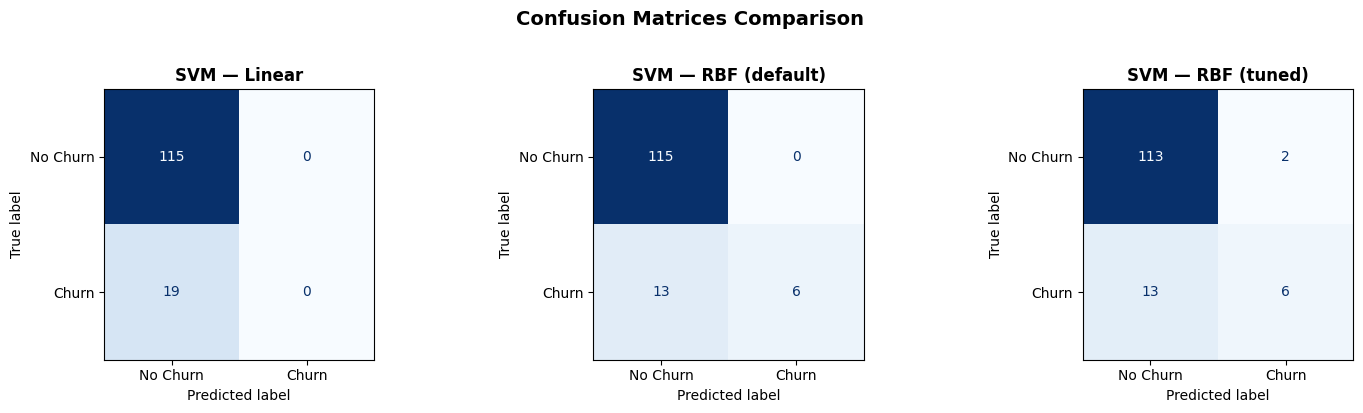

Saved: confusion_matrices.png


In [10]:
# ============================================================
# STEP 7: Confusion Matrices (Side-by-Side)
# ============================================================

print("\n" + "=" * 60)
print("STEP 7: Confusion Matrices")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
configs = [
    (y_pred_linear, "SVM — Linear"),
    (y_pred_rbf,    "SVM — RBF (default)"),
    (y_pred_best,   "SVM — RBF (tuned)"),
]
for ax, (preds, title) in zip(axes, configs):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(title, fontweight="bold")

plt.suptitle("Confusion Matrices Comparison", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()
print("Saved: confusion_matrices.png")


STEP 8: ROC Curves


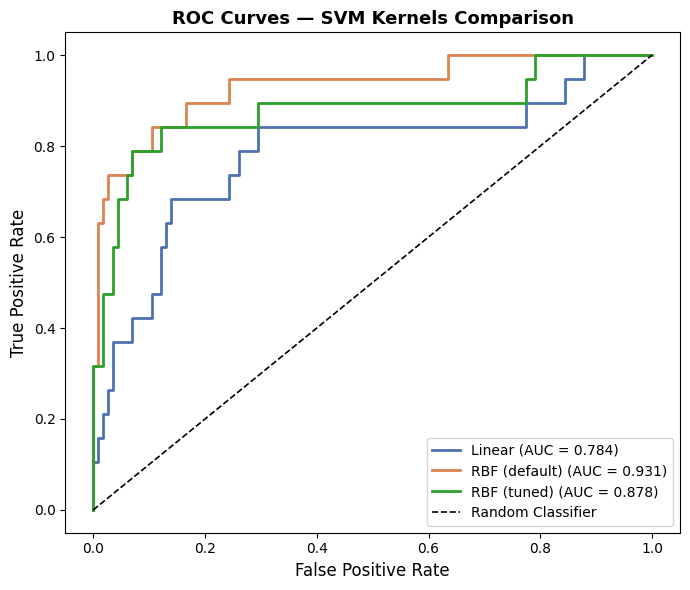

Saved: roc_curves.png


In [11]:
# ============================================================
# STEP 8: ROC Curves — All Three Models
# ============================================================

print("\n" + "=" * 60)
print("STEP 8: ROC Curves")
print("=" * 60)

fig, ax = plt.subplots(figsize=(7, 6))

for probs, label, color in [
    (y_prob_linear, "Linear",    "#4C72B0"),
    (y_prob_rbf,    "RBF (default)", "#DD8452"),
    (y_prob_best,   "RBF (tuned)",   "#2CA02C"),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{label} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random Classifier")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — SVM Kernels Comparison", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()
print("Saved: roc_curves.png")


STEP 9: Decision Boundary (PCA 2D Projection)
Variance explained by 2 PCA components: 25.31%


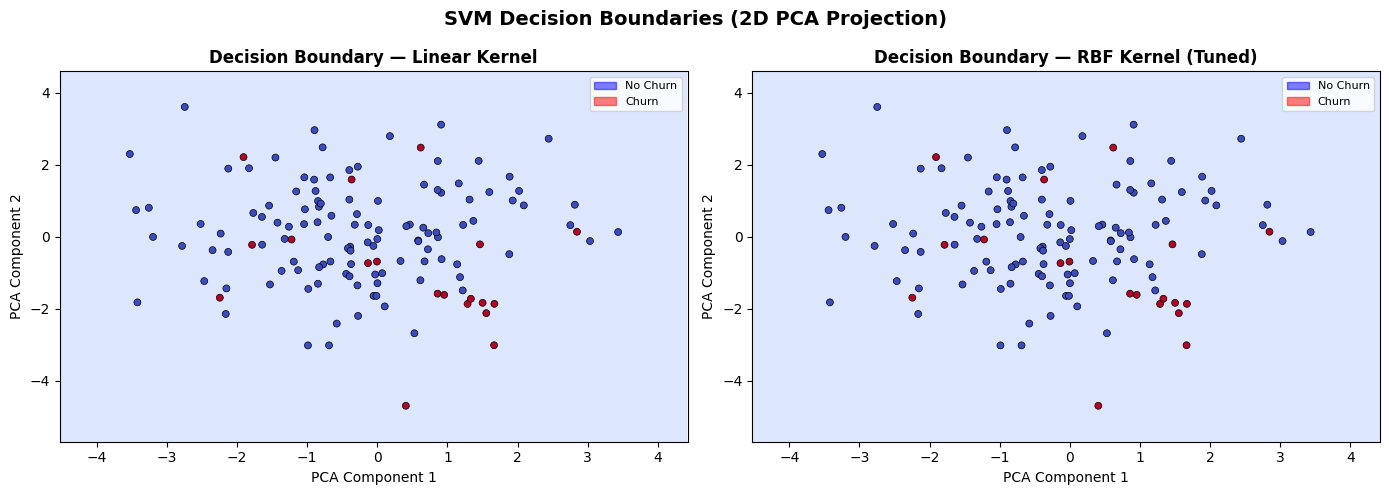

Saved: decision_boundary.png


In [12]:
# ============================================================
# STEP 9: Decision Boundary Visualization (2D via PCA)
# ============================================================

print("\n" + "=" * 60)
print("STEP 9: Decision Boundary (PCA 2D Projection)")
print("=" * 60)

# Reduce to 2 PCA components for visualization
pca = PCA(n_components=2, random_state=42)
X_pca      = pca.fit_transform(X_scaled)
X_train_pca = pca.transform(X_train)
X_test_pca  = pca.transform(X_test)

print(f"Variance explained by 2 PCA components: "
      f"{pca.explained_variance_ratio_.sum() * 100:.2f}%")

def plot_decision_boundary(model, X_tr, y_tr, X_te, y_te, title, ax):
    """Fit model on 2D PCA data and plot the decision boundary."""
    model_2d = type(model)(**model.get_params())
    model_2d.fit(X_tr, y_tr)

    h = 0.05
    x_min, x_max = X_te[:, 0].min() - 1, X_te[:, 0].max() + 1
    y_min, y_max = X_te[:, 1].min() - 1, X_te[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    scatter = ax.scatter(X_te[:, 0], X_te[:, 1], c=y_te,
                         cmap="coolwarm", edgecolors="k", s=25, linewidths=0.5)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")

    patch0 = mpatches.Patch(color="blue",  alpha=0.5, label="No Churn")
    patch1 = mpatches.Patch(color="red",   alpha=0.5, label="Churn")
    ax.legend(handles=[patch0, patch1], loc="upper right", fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_decision_boundary(
    SVC(kernel="linear", C=1.0, probability=True, random_state=42),
    X_train_pca, y_train, X_test_pca, y_test,
    "Decision Boundary — Linear Kernel", axes[0]
)
plot_decision_boundary(
    SVC(kernel="rbf", **{k: v for k, v in grid_rbf.best_params_.items()},
        probability=True, random_state=42),
    X_train_pca, y_train, X_test_pca, y_test,
    "Decision Boundary — RBF Kernel (Tuned)", axes[1]
)

plt.suptitle("SVM Decision Boundaries (2D PCA Projection)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("decision_boundary.png", dpi=150)
plt.show()
print("Saved: decision_boundary.png")

In [13]:
# ============================================================
# STEP 10: Cross-Validation
# ============================================================

print("\n" + "=" * 60)
print("STEP 10: 5-Fold Cross-Validation (Tuned RBF)")
print("=" * 60)

for metric_name, scorer in [("Accuracy","accuracy"), ("Precision","precision"),
                              ("Recall","recall"), ("F1","f1"), ("AUC","roc_auc")]:
    scores = cross_val_score(svm_best, X_scaled, y, cv=5, scoring=scorer)
    print(f"  {metric_name:10s}: {scores.mean():.4f} ± {scores.std():.4f}")



STEP 10: 5-Fold Cross-Validation (Tuned RBF)
  Accuracy  : 0.8980 ± 0.0102
  Precision : 0.8088 ± 0.1119
  Recall    : 0.3895 ± 0.0788
  F1        : 0.5167 ± 0.0697
  AUC       : 0.8772 ± 0.0396



STEP 11: Model Comparison Summary
               Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                        
Linear           0.8582       0.00  0.0000    0.0000   0.7840
RBF (default)    0.9030       1.00  0.3158    0.4800   0.9309
RBF (tuned)      0.8881       0.75  0.3158    0.4444   0.8778


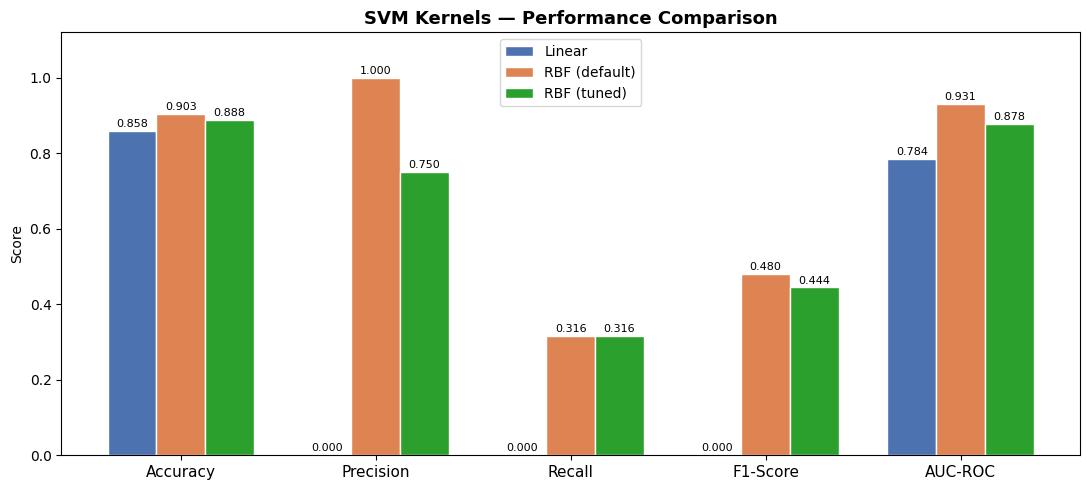

Saved: model_comparison.png

ALL STEPS COMPLETE!

SUMMARY
-------
1.  Loaded & explored Churn dataset (20 features, binary target).
2.  Preprocessed: encoded categoricals, dropped State/Area code,
    applied StandardScaler (essential for SVM).
3.  80/20 stratified train-test split.
4.  Trained SVM with Linear kernel → evaluated.
5.  Trained SVM with RBF kernel (default params) → evaluated.
6.  Tuned RBF kernel with GridSearchCV (C, gamma) → best model.
7.  Side-by-side Confusion Matrices for all three models.
8.  ROC Curves with AUC scores for all three models.
9.  Decision Boundary visualized via 2D PCA projection.
10. 5-fold Cross-Validation on tuned model (Acc, Prec, Rec, F1, AUC).
11. Full metric comparison table + grouped bar chart.
 
Saved plots:
  class_distribution.png
  confusion_matrices.png
  roc_curves.png
  decision_boundary.png
  model_comparison.png



In [14]:
# ============================================================
# STEP 11: Full Model Comparison Summary
# ============================================================

print("\n" + "=" * 60)
print("STEP 11: Model Comparison Summary")
print("=" * 60)

models   = ["Linear",        "RBF (default)",   "RBF (tuned)"]
y_preds  = [y_pred_linear,   y_pred_rbf,        y_pred_best]
y_probs  = [y_prob_linear,   y_prob_rbf,        y_prob_best]

summary = pd.DataFrame({
    "Model"    : models,
    "Accuracy" : [accuracy_score(y_test, p) for p in y_preds],
    "Precision": [precision_score(y_test, p) for p in y_preds],
    "Recall"   : [recall_score(y_test, p) for p in y_preds],
    "F1-Score" : [f1_score(y_test, p) for p in y_preds],
    "AUC-ROC"  : [roc_auc_score(y_test, pr) for pr in y_probs],
}).set_index("Model")

print(summary.round(4))

# ── Grouped bar chart ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
x     = np.arange(len(summary.columns))
width = 0.25
colors = ["#4C72B0", "#DD8452", "#2CA02C"]

for i, (model, row) in enumerate(summary.iterrows()):
    bars = ax.bar(x + i * width, row.values, width,
                  label=model, color=colors[i], edgecolor="white")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(summary.columns, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("SVM Kernels — Performance Comparison", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()
print("Saved: model_comparison.png")

print("\n" + "=" * 60)
print("ALL STEPS COMPLETE!")
print("=" * 60)
print("""
SUMMARY
-------
1.  Loaded & explored Churn dataset (20 features, binary target).
2.  Preprocessed: encoded categoricals, dropped State/Area code,
    applied StandardScaler (essential for SVM).
3.  80/20 stratified train-test split.
4.  Trained SVM with Linear kernel → evaluated.
5.  Trained SVM with RBF kernel (default params) → evaluated.
6.  Tuned RBF kernel with GridSearchCV (C, gamma) → best model.
7.  Side-by-side Confusion Matrices for all three models.
8.  ROC Curves with AUC scores for all three models.
9.  Decision Boundary visualized via 2D PCA projection.
10. 5-fold Cross-Validation on tuned model (Acc, Prec, Rec, F1, AUC).
11. Full metric comparison table + grouped bar chart.

Saved plots:
  class_distribution.png
  confusion_matrices.png
  roc_curves.png
  decision_boundary.png
  model_comparison.png
""")